In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from scipy.stats import expon
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
from copulas.multivariate import GaussianMultivariate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
import numpy as np
import umap

/home/chucho/Projects/Realistic_TCMS_simulation/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### column differentiation:

In [2]:
#nomi delle colonne da generare
columns_to_generate = [
    'Durata','CabEnabled_M1', 'CabEnabled_M8', 'ERTMS_PiastraSts', 'HMI_ACPntSts_T2', 'HMI_ACPntSts_T7', 'HMI_DCPntSts_T2',
    'HMI_DCPntSts_T7', 'HMI_Iline', 'HMI_Irsts_T2', 'HMI_Irsts_T7', 'HMI_VBatt_T2', 'HMI_VBatt_T4', 'HMI_VBatt_T5',
    'HMI_VBatt_T7', 'HMI_Vline', 'HMI_impSIL', 'LineVoltType', 'MDS_LedLimVel', 'MDS_StatoMarcia', '_GPS_LAT',
    '_GPS_LON', 'ldvvelimps', 'ldvveltreno', 'usB1BCilPres_M1', 'usB1BCilPres_M3', 'usB1BCilPres_M6', 'usB1BCilPres_M8',
    'usB1BCilPres_T2', 'usB1BCilPres_T4', 'usB1BCilPres_T5', 'usB1BCilPres_T7', 'usB2BCilPres_M1', 'usB2BCilPres_M3',
    'usB2BCilPres_M6', 'usB2BCilPres_M8', 'usB2BCilPres_T2', 'usB2BCilPres_T4', 'usB2BCilPres_T5', 'usB2BCilPres_T7',
    'usBpPres', 'usMpPres'
]

non_numeric_cols = [
        'Descrizione',
        'Timestamp chiusura',
        'Posizione',
        'Flotta',
        'Veicolo',
        'Codice',
        'Nome',
        'Test',
        'Sistema',
        'Componente',
        'Timestamp segnale']

### reading the csv:

In [88]:
dataset = pd.read_csv('dataset.csv')
dataset_new = dataset.copy()
dataset_new['Timestamp'] = pd.to_datetime(dataset_new['Timestamp'], errors='coerce')
# timestamp will be essential
dataset_new = dataset_new.dropna(subset=['Timestamp'])
# repeated signals:
dataset_new = dataset_new.drop_duplicates(subset=['Descrizione', 'Timestamp'])

### some observations:

#### concurrent signals (clock granularity)
print('"freq" is the number of different events arriving at a same timestamp.')
dataset_new.groupby('Timestamp')['Flotta'].describe().groupby('freq').count()['count']

In [12]:
print("types of non numeric columns")
dataset_new[non_numeric_cols].nunique()

types of non numeric columns


Descrizione             402
Timestamp chiusura    10319
Posizione                95
Flotta                    1
Veicolo                   1
Codice                  545
Nome                    287
Test                      1
Sistema                  17
Componente              178
Timestamp segnale      7015
dtype: int64

#### top components and systems:

In [6]:
dataset_new['Sistema'].unique()

array(['HVAC', 'VEHICLE', 'AT', 'MDS', 'BANCO', 'FRENO', 'PORTE_INT',
       'TRAZIONE', 'LVOLT', 'PORTE_EST', 'SCMT', 'TOILETTE', 'TCMS',
       'CARRELLI', 'ANTINCENDIO', 'AUSILIARI', 'MT'], dtype=object)

In [7]:
dataset_new['Componente'].unique()

array(['HVAC_T5', 'HVAC_CAB_M1', 'VEHICLE', 'T2_1Q2_IR', 'T2_MCB',
       'T2_PANTO', 'T7_MCB', 'T7_PANTO', 'MDS', 'T7_1Q2_IR', 'M1_4K14',
       'FRENO', 'HVAC_M8', 'M3_Porta_gangway_2', 'HVAC_T4', 'HVAC_T2',
       'CONV_TRAZ_M6', 'CONV_TRAZ_M1', 'M1_9K42', 'M8_9K42', 'T2_1Q4_IP',
       'TCU_M8', 'CONV_TRAZ_M8', 'CONV_TRAZ_M3', 'T7_1Q4_IP',
       'M3_Gradino_Porta4', 'SCMT_M1', 'BCU_M1', 'HVAC_M6', 'HVAC_CAB_M8',
       'M1_Porta_gangway_1', 'SCMT_M8', 'TOIL_T7', 'M6_Porta_gangway_2',
       'T5_Porta_gangway_1', 'T5_Porta_gangway_2', 'T7_Porta_gangway_2',
       'M6_Porta_gangway_1', 'TCU_M3', 'T2_1Q7', 'Q1_M1', 'AT',
       'T2_Porta_gangway_2', 'M8_Porta_gangway_1', 'T7_Porta_gangway_1',
       'TCU_M6', 'TCU_M1', 'LCU4_T5', 'T4_Porta_gangway_1', 'EDCU_M6_3',
       'HVAC_M3', 'HVAC_T7', 'M6_Gradino_Porta1', 'EDCU_T4_2',
       'EDCU_T2_1', 'CARRELLI', 'Ungibordo_M8', 'HUNTING_T2',
       'T4_Porta_gangway_2', 'EDCU_M3_1', 'M6_Gradino_Porta2',
       'EDCU_M3_3', 'EDCU_M6_4', 'B

#### how many events are there?

In [17]:
dataset['Descrizione'].nunique()

402

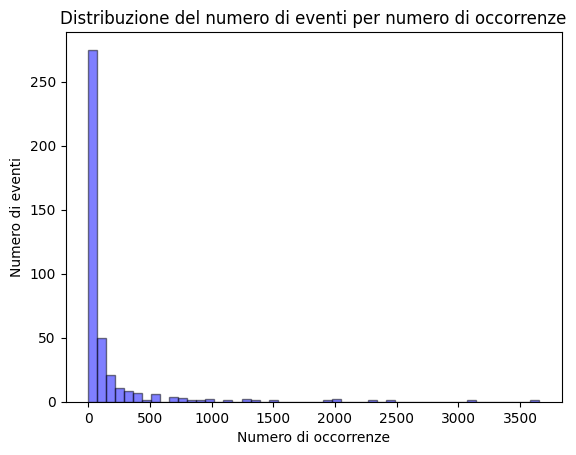

In [23]:
event_occurrences = dataset.groupby('Descrizione').count().sort_values('Flotta')['Flotta'].values

plt.hist(event_occurrences, bins=50, alpha=0.5, color='blue', edgecolor='black')
plt.title('Distribuzione del numero di eventi per numero di occorrenze')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Numero di eventi')
plt.show()


#### some other plots:

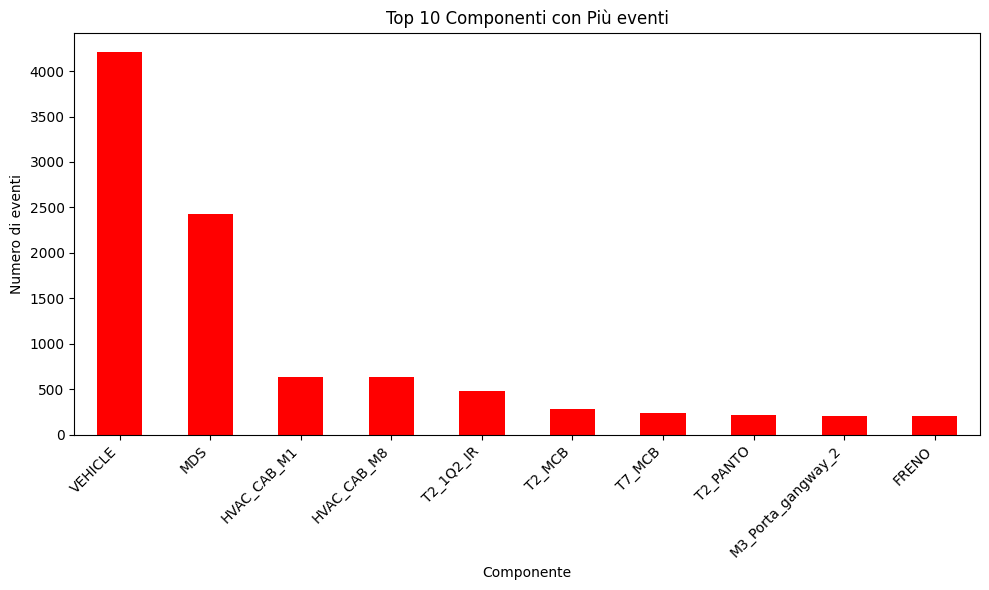

In [8]:
# popular "componente"
eventi_per_sistema = dataset_new.groupby(['Componente']).count()['Flotta']

top_events = eventi_per_sistema.nlargest(10)
plt.figure(figsize=(10, 6))
top_events.plot(kind='bar', color='red')
plt.title('Top 10 Componenti con Più eventi')
plt.xlabel('Componente')
plt.ylabel('Numero di eventi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



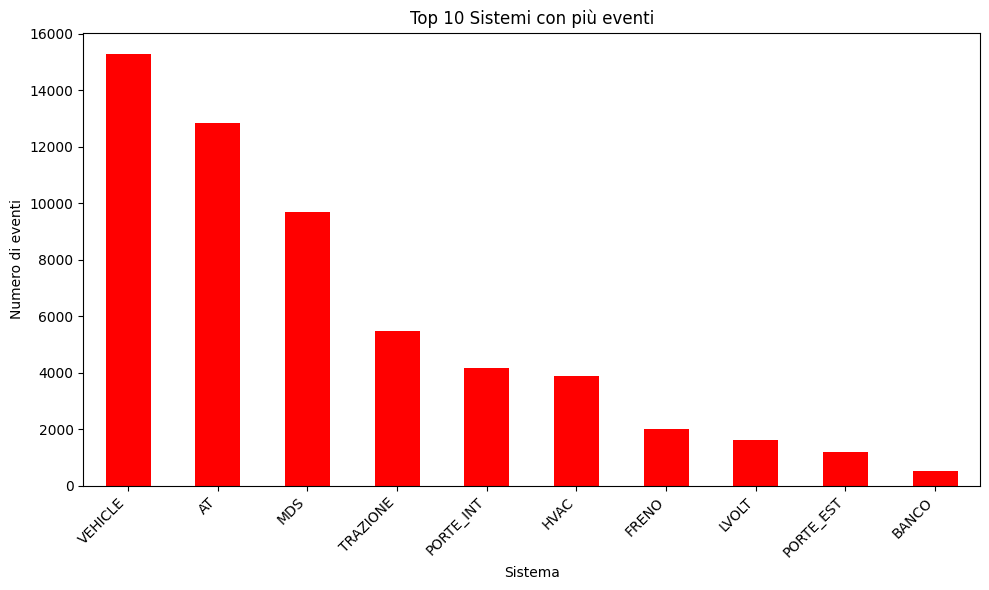

In [9]:
# popular "sistema"
eventi_per_sistema = dataset.groupby(['Sistema']).count()['Flotta']

top_events = eventi_per_sistema.nlargest(10)
plt.figure(figsize=(10, 6))
top_events.plot(kind='bar', color='red')
plt.title('Top 10 Sistemi con più eventi')
plt.xlabel('Sistema')
plt.ylabel('Numero di eventi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



### filtering

==================== Teniamo soltanto i 3 componenti e i sistemi più popolari ====================
Numero di righe prima del filtraggio: 57652
Numero di colonne prima della rimozione di colonne vuote: 169
Numero di righe dopo il filtraggio: 6366
Numero di colonne dopo la rimozione di colonne vuote: 56
======= a valle dei filtraggi ====================
==================== STATISTICHE DI NUMERO DI OCCORRENZE DI EVENTI ====================
count      51.000000
mean      124.823529
std       276.110247
min         1.000000
25%        23.500000
50%        40.000000
75%       101.500000
max      1486.000000
Name: Flotta, dtype: float64


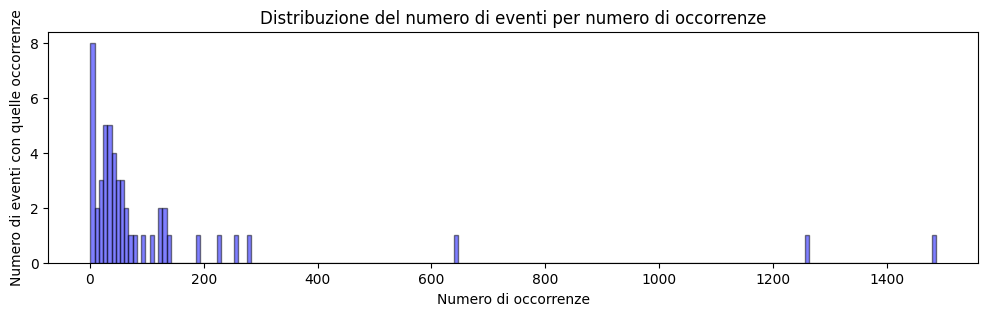

==================== PROPOSTA ====================
più raro è l'evento, più si può considerare essere un'anomalia.
Quale è il valore minimo di occorrenze di un evento tale per cui esso NON è un'anomalia???.
IL 25% degli eventi succede massimo 23.5  volte!
IL 50% degli eventi succede massimo 40.0  volte!
L 75% degli eventi succede massimo 101.5  volte!
Consideriamo anomalia tutto ciò che succede massimo 33.0 volte, corrispondete al quantile 0.4!
==================== Così facendo abbiamo: ====================
nel nostro dataset abbiamo 51 TIPI DI EVENTI diversi
sparsi in un totale di 6366 record
di cui 350 corrispondono ad anomalie


In [117]:
dataset = pd.read_csv('dataset.csv')
dataset_new = dataset.copy()
dataset_new['Timestamp'] = pd.to_datetime(dataset_new['Timestamp'], errors='coerce')
# timestamp will be essential
dataset_new = dataset_new.dropna(subset=['Timestamp'])
# repeated signals:
dataset_new = dataset_new.drop_duplicates(subset=['Descrizione', 'Timestamp'])

largest = 3 
anomalous_quantile = 0.4

print('='*20, f'Teniamo soltanto i {3} componenti e i sistemi più popolari','='*20)

top_components = list(dataset_new.groupby(['Componente']).count()['Flotta'].nlargest(largest).index)
top_sistems = list(dataset_new.groupby(['Sistema']).count()['Flotta'].nlargest(largest).index)

print(f"Numero di righe prima del filtraggio: {dataset.shape[0]}")
print(f"Numero di colonne prima della rimozione di colonne vuote: {dataset.shape[1]}")

dataset_new = dataset_new[dataset_new['Componente'].isin(top_components)]
dataset_new = dataset_new[dataset_new['Sistema'].isin(top_sistems)]

dataset_new = dataset_new.dropna(axis=1, how='all')
dataset_new = dataset_new.dropna()
dataset_new.set_index('Timestamp', inplace=True)
print(f"Numero di righe dopo il filtraggio: {dataset_new.shape[0]}")
print(f"Numero di colonne dopo la rimozione di colonne vuote: {dataset_new.shape[1]}")

print(f'======= a valle dei filtraggi ====================')


events_and_occurrences = dataset_new.groupby('Descrizione').count()['Flotta']
print('='*20, 'STATISTICHE DI NUMERO DI OCCORRENZE DI EVENTI','='*20)
print(events_and_occurrences.describe())
event_occurrences = dataset_new.groupby('Descrizione').count().sort_values('Flotta')['Flotta']
plt.figure(figsize=(12, 3))
plt.hist(event_occurrences.values, bins=200, alpha=0.5, color='blue', edgecolor='black')
plt.title('Distribuzione del numero di eventi per numero di occorrenze')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Numero di eventi con quelle occorrenze')
plt.show()

print('='*20, 'PROPOSTA','='*20)
print('più raro è l\'evento, più si può considerare essere un\'anomalia.')
print('Quale è il valore minimo di occorrenze di un evento tale per cui esso NON è un\'anomalia???.')
print('IL 25% degli eventi succede massimo', events_and_occurrences.quantile(.25), ' volte!')
print('IL 50% degli eventi succede massimo', events_and_occurrences.quantile(.50), ' volte!')
print('L 75% degli eventi succede massimo', events_and_occurrences.quantile(.75), ' volte!')
min_occorrences_for_beign_normal = events_and_occurrences.quantile(anomalous_quantile)
print(f'Consideriamo anomalia tutto ciò che succede massimo {min_occorrences_for_beign_normal} volte, corrispondete al quantile {anomalous_quantile}!')

print('='*20, 'Così facendo abbiamo:','='*20)

eventi_totali = dataset_new['Descrizione'].nunique()
print(f'nel nostro dataset abbiamo {eventi_totali} TIPI DI EVENTI diversi')
record_totali = len(dataset_new)
print(f'sparsi in un totale di {record_totali} record')

anomalies = event_occurrences[event_occurrences <= min_occorrences_for_beign_normal].index


record_anomalie = len(dataset_new[dataset_new['Descrizione'].isin(anomalies)])
print(f'di cui {record_anomalie} corrispondono ad anomalie')

### some other observations:

In [108]:
dataset_new[non_numeric_cols].nunique()

Descrizione             51
Timestamp chiusura    5617
Posizione               84
Flotta                   1
Veicolo                  1
Codice                  60
Nome                    52
Test                     1
Sistema                  2
Componente               2
Timestamp segnale     3890
dtype: int64

In [109]:
dataset_new.groupby(['Codice','Nome','Descrizione'])['Flotta'].count()

Codice          Nome               Descrizione                                            
011200          CCU_FltWtbR1       Mancata ricezione R1 in CCU M1                               29
011201          CCU_FltWtbR2       Mancata ricezione R2 in CCU M1                               32
011202          CCU_FltWtbComm     Mancata comunicazione WTB in CCU M1                          61
011203          CCU_GtwFlt         Guasto GTW semitreno M1-T4                                    1
018200          CCU_FltWtbR1       Mancata ricezione R1 in CCU M8                               23
018201          CCU_FltWtbR2       Mancata ricezione R2 in CCU M8                               34
018202          CCU_FltWtbComm     Mancata comunicazione WTB in CCU M8                          56
020006          _NokVoltSts_       Incoerenza Tensione di Linea                                  1
150004          _LineVoltType_     Selezionata tensione 3 kV                                     9
150005          _L

In [110]:
dataset_new.groupby(['Posizione'])['Flotta'].count()

Posizione
Antegnate           2
Aurisina Cave       1
Botticino          31
Brendola           30
Brescia           214
                 ... 
Venezia          2039
Verona            229
Vicenza           249
Vimodrone          37
Visogliano          3
Name: Flotta, Length: 84, dtype: int64

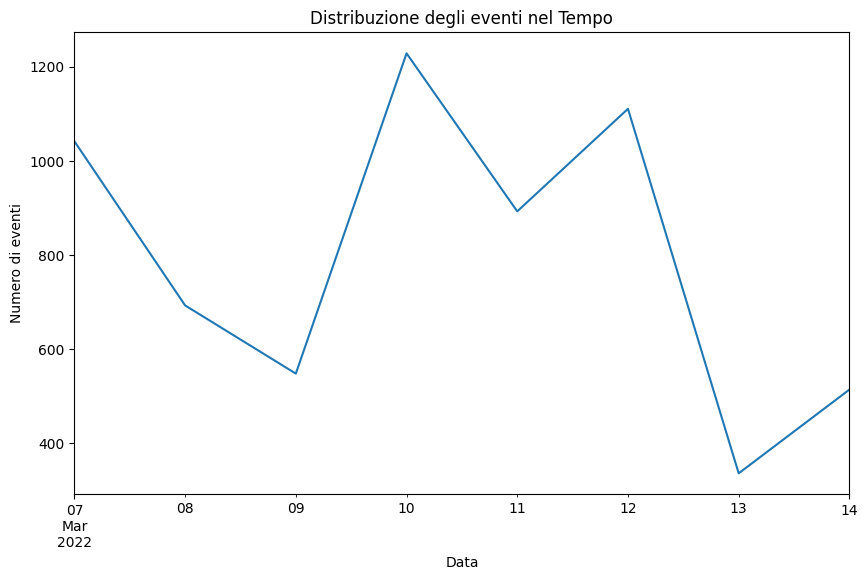

In [111]:
#visualizzazione della distribazione degli eventi nel tempo
dataset_new.resample('D').size().plot(title='Distribuzione degli eventi nel Tempo', figsize=(10, 6))
plt.xlabel('Data')
plt.ylabel('Numero di eventi')
plt.show()

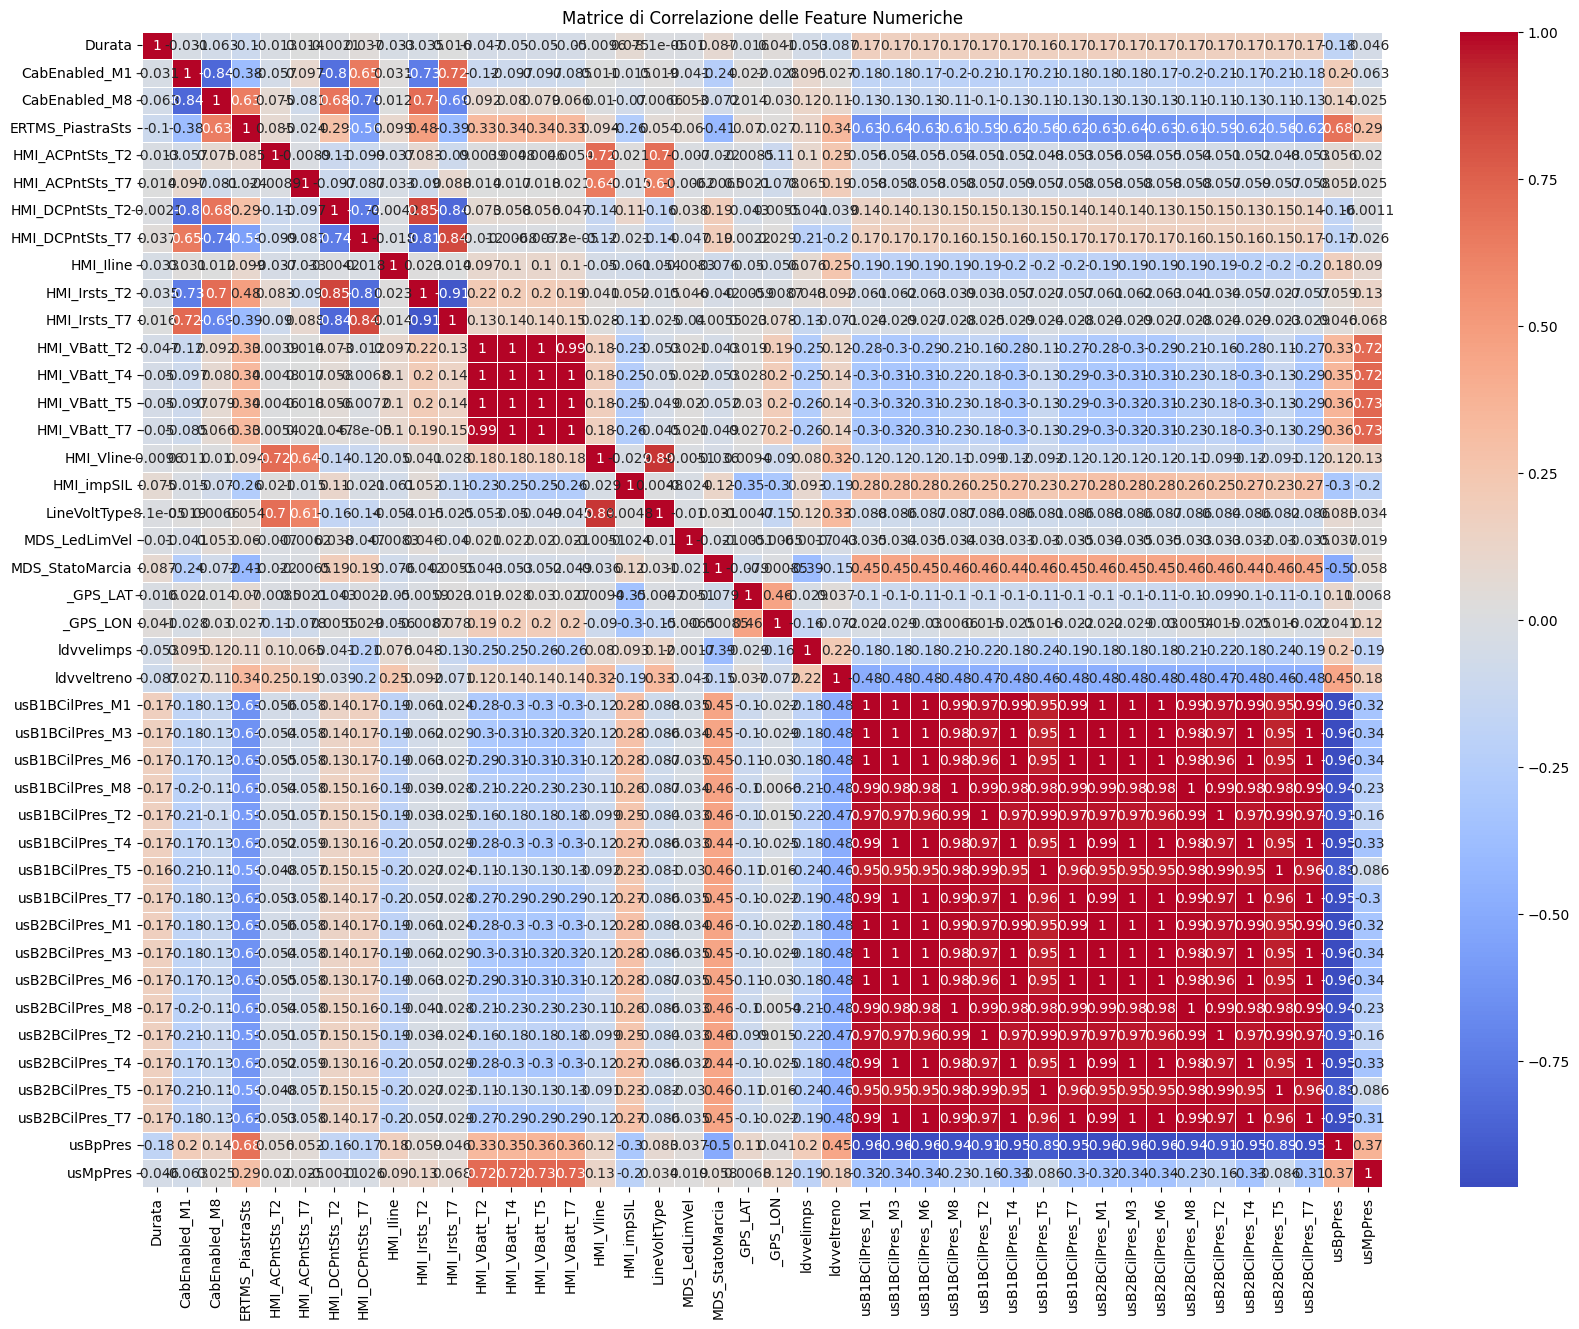

In [112]:
#matrice di correlazione
correlation_matrix = dataset_new[columns_to_generate].corr()
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice di Correlazione delle Feature Numeriche')
plt.show()

## Looking for statistical correlations 
______________________

Premise: 
- we are not taking into account the time-series nature of data, just tabular stuff.
- between numerical (i.e. from sensors) and non-numerical (i.e. from labels) data.
- "correlation" is intended ALSO in the non-linear setting. (we use UMAP)

Let's create a non linear 2D reduction of the numerical data at hand:

In [ ]:
X = dataset_new[columns_to_generate].values
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
# Fit and transform the data
embedding = reducer.fit_transform(X.reshape(X.shape[0], -1))

### there is ALMOST NONE correlation between records and Events:


==========Eventi più popolari:==========
Descrizione
Cod. 03 Comando di frenatura da manipolatore attivo        1486
Cod. 13 Leva MC 6S01 non in trazione                       1263
Cod. 04 Condotta Generale scarica                           645
Cod. 22 Manettino fuori coasting dopo taglio trazione       276
Cod. 05 Taglio trazione da SSB attivo                       255
Pressione CP sotto 8.5 bar in M8 (press. 9S14)              226
Cod. 08 Loop porte aperto                                   189
Cod. 12 Rilascio Porte Sinistre Attivo                      138
Cod. 01 Max fren. di servizio richiesta da segnalamento     133
Cod. 14 Nessuna direzione impostata                         133
Name: Flotta, dtype: int64


Il dataset con i 10 eventi più gettonati è lungo  4744 record
{'Cod. 03 Comando di frenatura da manipolatore attivo': 0, 'Cod. 13 Leva MC 6S01 non in trazione': 1, 'Cod. 04 Condotta Generale scarica': 2, 'Cod. 22 Manettino fuori coasting dopo taglio trazione': 3, 'Cod. 05 Tagli

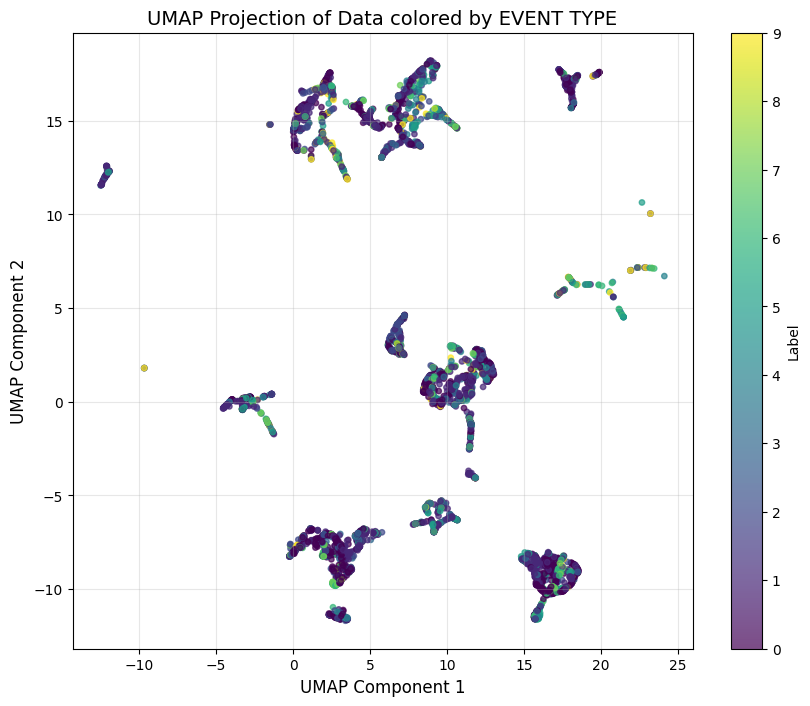

In [121]:
print("==========Eventi più popolari:==========")
print(dataset_new.groupby('Descrizione').count()['Flotta'].nlargest(10))
popular_descriptions = dataset_new.groupby('Descrizione')['Flotta'].count().nlargest(10).index
popular_events_ds = dataset_new[dataset_new['Descrizione'].isin(popular_descriptions)]
print("\n\n","="*50)
print('Il dataset con i 10 eventi più gettonati è lungo ',len(popular_events_ds), 'record')
print("="*50)
description_map = {desc: i for i, desc in enumerate(popular_descriptions)}
descrizioni_numeriche = popular_events_ds['Descrizione'].map(description_map)
print(description_map)

event_embedding = embedding[dataset_new['Descrizione'].isin(popular_descriptions)]
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(event_embedding[:, 0], event_embedding[:, 1], c=descrizioni_numeriche, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by EVENT TYPE', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()


### There is ALMOST NONE correlation between numerical features and POSITION:




==========Posizioni più popolari:==========
Posizione
Venezia                 2039
Milano                  1418
Trieste                  294
Vicenza                  249
Verona                   229
Brescia                  214
Padova                   186
Peschiera del Garda      120
Ronchi dei Legionari     110
Portogruaro              105
Name: Flotta, dtype: int64
il dataset con i 10 eventi più gettonati è le 10 posizioni più gettonate e lungo  6366 record
{'Venezia': 0, 'Milano': 1, 'Trieste': 2, 'Vicenza': 3, 'Verona': 4, 'Brescia': 5, 'Padova': 6, 'Peschiera del Garda': 7, 'Ronchi dei Legionari': 8, 'Portogruaro': 9}


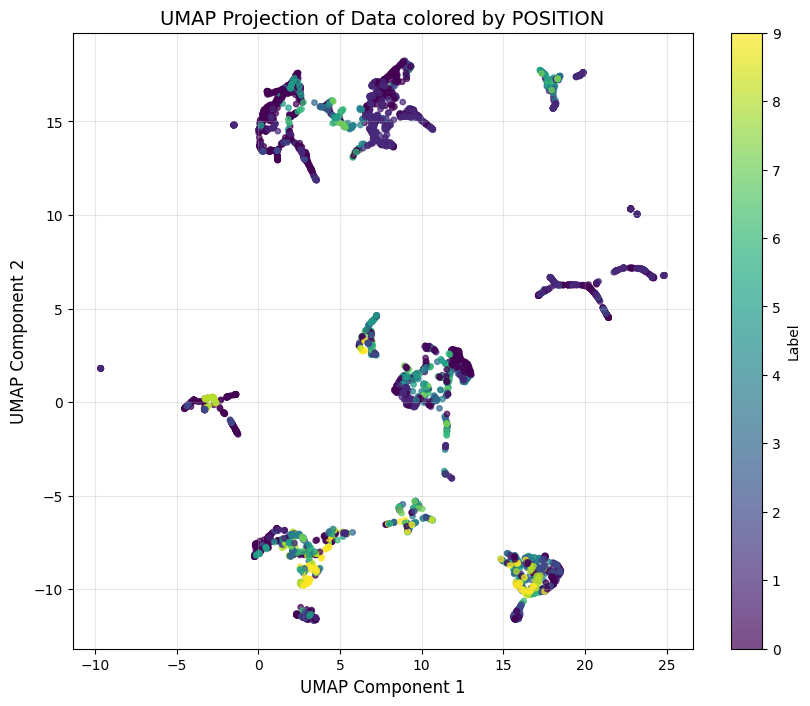

In [120]:

print("\n\n\n==========Posizioni più popolari:==========")
print(dataset_new.groupby('Posizione')['Flotta'].count().nlargest(10))
popular_positions = dataset_new.groupby('Posizione')['Flotta'].count().nlargest(10).index
popular_positions_ds = dataset_new[dataset_new['Posizione'].isin(popular_positions)]
print("="*50)
print('il dataset con i 10 eventi più gettonati è le 10 posizioni più gettonate e lungo ',len(dataset_new), 'record')
print("="*50)
position_map = {desc: i for i, desc in enumerate(popular_positions)}
posizioni_numeriche = popular_positions_ds['Posizione'].map(position_map)
positions_embedding = embedding[dataset_new['Posizione'].isin(popular_positions)]
print(position_map)
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(positions_embedding[:, 0], positions_embedding[:, 1], c=posizioni_numeriche, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by POSITION', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

Qui sembra che abbiamo  una leggerissima correlazione tra il posto in cui succedono gli eventi e i valori di alcuni sensori... ma solo per alcune posizioni.

### There is ALMONS NONE correlation between "anomalies" and normal records:

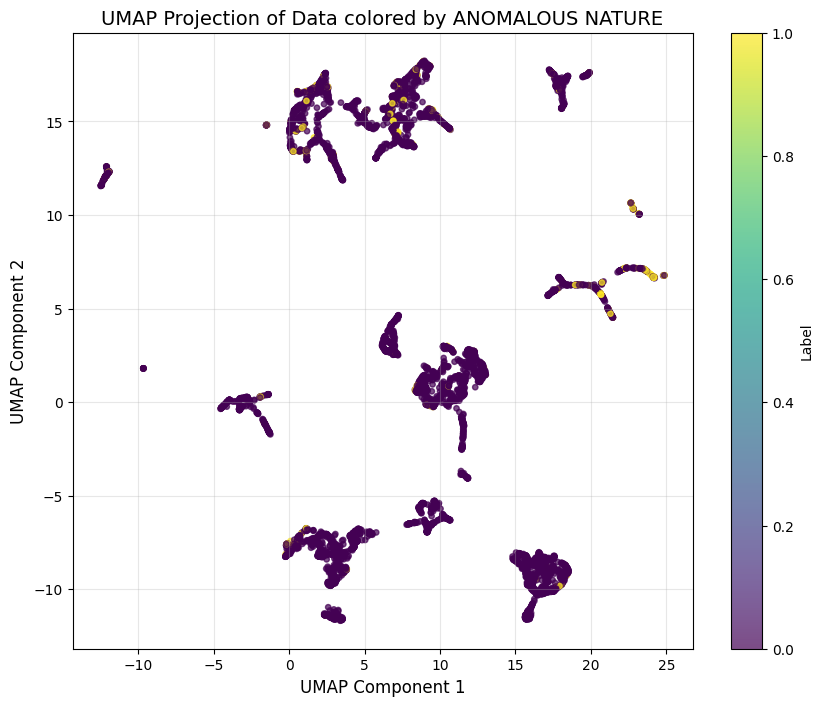

In [122]:
anomalous = dataset_new['Descrizione'].isin(anomalies).values
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=anomalous, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by ANOMALOUS NATURE', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()